In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

# 1. Defining the single ZIP file is stored in Drive, and where to put it locally
drive_zip_path = "/content/drive/MyDrive/BraTS2020_Full.zip"
local_zip_path = "/content/BraTS2020_Full.zip"
local_extract_folder = "/content/brats_local_data/"

# 2. Copy the zip file from Drive to Colab's high-speed local SSD
print("Copying zip from Google Drive to local storage...")
!cp "{drive_zip_path}" "{local_zip_path}"

# 3. Unzip the files silently (-q) into the local folder
print("Unzipping dataset to local directory...")
!unzip -n -q "{local_zip_path}" -d "{local_extract_folder}"
print("Done! Data is ready for high-speed training.")

Copying zip from Google Drive to local storage...
Unzipping dataset to local directory...
Done! Data is ready for high-speed training.


In [ ]:
import os

# Point straight to your unzipped folder
data_path = '/content/brats_local_data/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData'

# Read the folder directly
patients = os.listdir(data_path)

print(f"🔎 DIAGNOSTIC RESULTS:")
print(f"Total patient folders actually inside local storage: {len(patients)}")
print(f"First few folders found: {patients[:3]}")

🔎 DIAGNOSTIC RESULTS:
Total patient folders actually inside local storage: 371
First few folders found: ['BraTS20_Training_128', 'BraTS20_Training_037', 'BraTS20_Training_308']


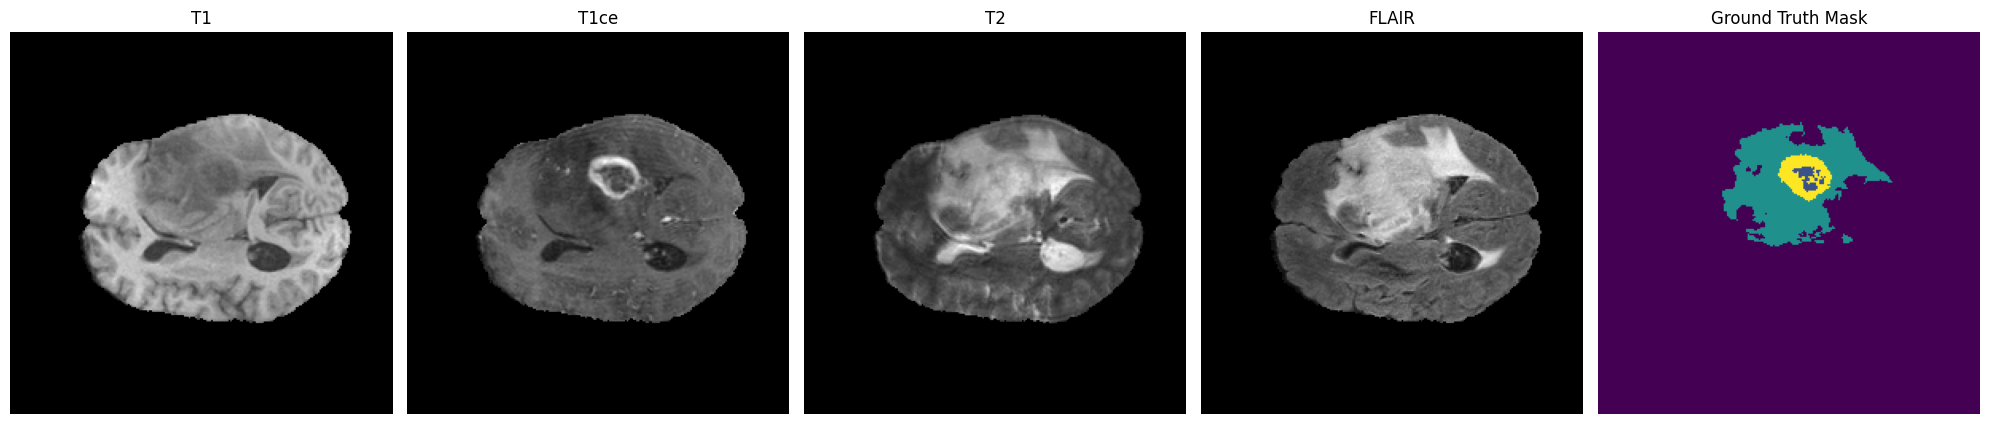

In [ ]:
import os
import nibabel as nib
import matplotlib.pyplot as plt

# look at the local unzipped folder instead of Drive
data_path = '/content/brats_local_data/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData'

# 1. discovery logic
patient_id = 'BraTS20_Training_001'
patient_path = f'{data_path}/{patient_id}'

# 2. Define specific paths for the 4 modalities and segmentation mask
t1_path = f'{patient_path}/{patient_id}_t1.nii'
t1ce_path = f'{patient_path}/{patient_id}_t1ce.nii'
t2_path = f'{patient_path}/{patient_id}_t2.nii'
flair_path = f'{patient_path}/{patient_id}_flair.nii'
seg_path = f'{patient_path}/{patient_id}_seg.nii'

# 3. Load 3D arrays
t1_img = nib.load(t1_path).get_fdata()
t1ce_img = nib.load(t1ce_path).get_fdata()
t2_img = nib.load(t2_path).get_fdata()
flair_img = nib.load(flair_path).get_fdata()
seg_img = nib.load(seg_path).get_fdata()

# 4. Pick a middle slice
slice_idx = 75

# 5. Plot!
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

axes[0].imshow(t1_img[:, :, slice_idx], cmap='gray')
axes[0].set_title('T1')
axes[0].axis('off')

axes[1].imshow(t1ce_img[:, :, slice_idx], cmap='gray')
axes[1].set_title('T1ce')
axes[1].axis('off')

axes[2].imshow(t2_img[:, :, slice_idx], cmap='gray')
axes[2].set_title('T2')
axes[2].axis('off')

axes[3].imshow(flair_img[:, :, slice_idx], cmap='gray')
axes[3].set_title('FLAIR')
axes[3].axis('off')

axes[4].imshow(seg_img[:, :, slice_idx], cmap='viridis')
axes[4].set_title('Ground Truth Mask')
axes[4].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

# 1. Define a helper function to normalize the pixels between 0 and 1
def normalize_image(img_slice):
    # We find the min and max pixel values in the slice
    img_min = np.min(img_slice)
    img_max = np.max(img_slice)

    # Avoid division by zero if a slice happens to be completely black
    if img_max == 0:
        return img_slice

    # The Min-Max scaling mathematical formula
    normalized = (img_slice - img_min) / (img_max - img_min)
    return normalized

# 2. Grab the raw slices from the previous cell and normalize them
t1_norm = normalize_image(t1_img[:, :, slice_idx])
t1ce_norm = normalize_image(t1ce_img[:, :, slice_idx])
t2_norm = normalize_image(t2_img[:, :, slice_idx])
flair_norm = normalize_image(flair_img[:, :, slice_idx])

# 3. Stack the 4 separate images into a single 4-channel "brick" of data
# axis=-1 tells Python to stack them like layers of a cake
X_input = np.stack([t1_norm, t1ce_norm, t2_norm, flair_norm], axis=-1)

# 4. Grab the ground-truth mask (No need to normalize, it's already classes 0, 1, 2, 4)
Y_label = seg_img[:, :, slice_idx]

# 5. Print the results to prove it worked
print(f"Original T1 slice shape: {t1_img[:, :, slice_idx].shape}")
print(f"Final Preprocessed AI Input Shape (X): {X_input.shape}")
print(f"Final Target Mask Shape (Y): {Y_label.shape}")
print(f"Max pixel value before normalization: {np.max(t1_img[:, :, slice_idx])}")
print(f"Max pixel value AFTER normalization: {np.max(t1_norm)}")

Original T1 slice shape: (240, 240)
Final Preprocessed AI Input Shape (X): (240, 240, 4)
Final Target Mask Shape (Y): (240, 240)
Max pixel value before normalization: 636.0
Max pixel value AFTER normalization: 1.0


In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate

def build_lightweight_unet(input_shape=(240, 240, 4), base_filters=16):
    # The Input Layer (Taking in our 4-channel stacked MRI data)
    inputs = Input(input_shape)

    # --- ENCODER (Downsampling) ---
    # Block 1: 16 filters instead of the standard 64
    c1 = Conv2D(base_filters, (3, 3), activation='relu', padding='same')(inputs)
    c1 = Conv2D(base_filters, (3, 3), activation='relu', padding='same')(c1)
    p1 = MaxPooling2D((2, 2))(c1)

    # Block 2: 32 filters
    c2 = Conv2D(base_filters * 2, (3, 3), activation='relu', padding='same')(p1)
    c2 = Conv2D(base_filters * 2, (3, 3), activation='relu', padding='same')(c2)
    p2 = MaxPooling2D((2, 2))(c2)

    # --- BOTTLENECK ---
    # Block 3: 64 filters (This is where the standard U-Net would have 1024!)
    c3 = Conv2D(base_filters * 4, (3, 3), activation='relu', padding='same')(p2)
    c3 = Conv2D(base_filters * 4, (3, 3), activation='relu', padding='same')(c3)

    # --- DECODER (Upsampling) ---
    # Up-Block 2
    u2 = UpSampling2D((2, 2))(c3)
    u2 = concatenate([u2, c2]) # The famous "Skip Connection"
    c4 = Conv2D(base_filters * 2, (3, 3), activation='relu', padding='same')(u2)
    c4 = Conv2D(base_filters * 2, (3, 3), activation='relu', padding='same')(c4)

    # Up-Block 1
    u1 = UpSampling2D((2, 2))(c4)
    u1 = concatenate([u1, c1])
    c5 = Conv2D(base_filters, (3, 3), activation='relu', padding='same')(u1)
    c5 = Conv2D(base_filters, (3, 3), activation='relu', padding='same')(c5)

    # --- OUTPUT LAYER ---
    # We output 4 channels (Background, NCR, ED, ET classes)
    outputs = Conv2D(4, (1, 1), activation='softmax')(c5)

    # Compile the model
    model = tf.keras.Model(inputs=[inputs], outputs=[outputs])
    return model

# Instantiate our custom model
light_model = build_lightweight_unet(base_filters=16)

# Print the architecture summary
light_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 240, 240,  │          0 │ -                 │
│ (InputLayer)        │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 240, 240,  │        592 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 240, 240,  │      2,320 │ conv2d[0][0]      │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 120, 120,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 120, 120,  │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 120, 120,  │      9,248 │ conv2d_2[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 60, 60,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 60, 60,    │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 60, 60,    │     36,928 │ conv2d_4[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 120, 120,  │          0 │ conv2d_5[0][0]    │
│ (UpSampling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 120, 120,  │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 96)               │            │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 120, 120,  │     27,680 │ concatenate[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 120, 120,  │      9,248 │ conv2d_6[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 240, 240,  │          0 │ conv2d_7[0][0]    │
│ (UpSampling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 240, 240,  │          0 │ up_sampling2d_1[… │
│ (Concatenate)       │ 48)               │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 240, 240,  │      6,928 │ concatenate_1[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 240, 240,  │      2,320 │ conv2d_8[0][0]  

 Total params: 118,468 (462.77 KB)

 Trainable params: 118,468 (462.77 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import os
import numpy as np
import nibabel as nib
import tensorflow as tf
from sklearn.model_selection import train_test_split

# ── Path — same root folder you already use ──────────────────────────────────
DATA_PATH = '/content/brats_local_data/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData'

# ── Slice selection ───────────────────────────────────────────────────────────
# BraTS volumes are 240×240×155.
# Slices 0-55 and 130-155 are mostly empty (no brain / no tumour).
# We keep only the informative middle band: indices 56-129  →  74 slices per patient.
SLICE_START = 56
SLICE_END   = 130          # exclusive  →  slices 56, 57, … 129

# ── Image size & classes ──────────────────────────────────────────────────────
IMG_HEIGHT  = 240
IMG_WIDTH   = 240
N_CHANNELS  = 4            # T1, T1ce, T2, FLAIR
N_CLASSES   = 4            # 0=Background, 1=NCR, 2=ED, 3=ET  (label 4 remapped → 3)

# ── Training hyper-params ─────────────────────────────────────────────────────
BATCH_SIZE  = 4
VAL_SPLIT   = 0.2          # 80 % train / 20 % val
RANDOM_SEED = 42

print("✅ Config loaded.")
print(f"   Data path  : {DATA_PATH}")
print(f"   Slice range: [{SLICE_START}, {SLICE_END})  →  {SLICE_END - SLICE_START} slices/patient")
print(f"   Input shape: ({IMG_HEIGHT}, {IMG_WIDTH}, {N_CHANNELS})")
print(f"   Classes    : {N_CLASSES}  (Background | NCR | Oedema | Enhancing Tumour)")

✅ Config loaded.
   Data path  : /content/brats_local_data/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData
   Slice range: [56, 130)  →  74 slices/patient
   Input shape: (240, 240, 4)
   Classes    : 4  (Background | NCR | Oedema | Enhancing Tumour)


In [ ]:
def get_patient_ids(data_path):
    """
    Scans the root data folder and returns a sorted list of patient IDs
    that contain all 5 required .nii files.
    """
    all_entries = sorted(os.listdir(data_path))
    valid_ids   = []

    for entry in all_entries:
        patient_path = os.path.join(data_path, entry)
        if not os.path.isdir(patient_path):
            continue

        # Check all 5 required files exist for this patient
        required_files = [
            f'{entry}_t1.nii',
            f'{entry}_t1ce.nii',
            f'{entry}_t2.nii',
            f'{entry}_flair.nii',
            f'{entry}_seg.nii',
        ]
        all_present = all(
            os.path.exists(os.path.join(patient_path, f))
            for f in required_files
        )
        if all_present:
            valid_ids.append(entry)
        else:
            print(f"   ⚠️  Skipping {entry} — missing one or more .nii files")

    return valid_ids


patient_ids = get_patient_ids(DATA_PATH)
print(f"✅ Found {len(patient_ids)} valid patients.")
print(f"   First 5: {patient_ids[:5]}")

   ⚠️  Skipping BraTS20_Training_355 — missing one or more .nii files
✅ Found 368 valid patients.
   First 5: ['BraTS20_Training_001', 'BraTS20_Training_002', 'BraTS20_Training_003', 'BraTS20_Training_004', 'BraTS20_Training_005']


In [ ]:
def normalize_volume(volume):
    """
    Min-Max normalisation applied per MRI volume (not per slice).
    Normalising the full 3D volume keeps intensity relationships consistent
    across slices — more stable than your current per-slice approach.
    Returns float32 array in [0, 1].
    """
    vol_min = np.min(volume)
    vol_max = np.max(volume)
    if vol_max == 0:          # blank scan edge case
        return volume.astype(np.float16)
    return ((volume - vol_min) / (vol_max - vol_min)).astype(np.float16)


def remap_labels(seg_volume):
    """
    BraTS ground-truth masks use class labels {0, 1, 2, 4}.
    Label 4 (Enhancing Tumour) MUST be remapped to 3 so that
    tf.one_hot(mask, depth=4) produces correct 4-channel output.

    Without this fix:
        tf.one_hot sees values 0,1,2,4  →  needs depth=5  →  channel 3 is always 0
        Your model's 4th output head never gets a training signal!
    """
    remapped = seg_volume.copy()
    remapped[remapped == 4] = 3
    return remapped.astype(np.uint8)


def load_patient_slices(patient_id, data_path,
                        slice_start=SLICE_START, slice_end=SLICE_END):
    """
    Loads one patient's 3D volumes, normalises, stacks channels, remaps labels.
    Returns:
        X  →  np.array of shape (n_slices, 240, 240, 4)  float32
        Y  →  np.array of shape (n_slices, 240, 240)     int32
    """
    patient_path = os.path.join(data_path, patient_id)

    # ── Load all 5 volumes ────────────────────────────────────────────────────
    t1    = nib.load(os.path.join(patient_path, f'{patient_id}_t1.nii')).get_fdata()
    t1ce  = nib.load(os.path.join(patient_path, f'{patient_id}_t1ce.nii')).get_fdata()
    t2    = nib.load(os.path.join(patient_path, f'{patient_id}_t2.nii')).get_fdata()
    flair = nib.load(os.path.join(patient_path, f'{patient_id}_flair.nii')).get_fdata()
    seg   = nib.load(os.path.join(patient_path, f'{patient_id}_seg.nii')).get_fdata()

    # ── Normalise each modality over its full 3D volume ───────────────────────
    t1    = normalize_volume(t1)
    t1ce  = normalize_volume(t1ce)
    t2    = normalize_volume(t2)
    flair = normalize_volume(flair)

    # ── Remap label 4 → 3  (CRITICAL — see docstring above) ──────────────────
    seg = remap_labels(seg)

    # ── Extract 2D axial slices from the informative band ─────────────────────
    X_slices, Y_slices = [], []
    for idx in range(slice_start, slice_end):
        # Stack 4 modality channels  →  shape (240, 240, 4)
        x = np.stack([
            t1   [:, :, idx],
            t1ce [:, :, idx],
            t2   [:, :, idx],
            flair[:, :, idx],
        ], axis=-1)

        y = seg[:, :, idx]   # shape (240, 240)  int32

        X_slices.append(x)
        Y_slices.append(y)

    return np.array(X_slices, dtype=np.float16), np.array(Y_slices, dtype=np.uint8)


# Quick sanity check on patient 001 (same one you've been working with)
X_test, Y_test = load_patient_slices('BraTS20_Training_001', DATA_PATH)
print(f"✅ Single-patient load OK")
print(f"   X shape : {X_test.shape}   (slices, H, W, channels)")
print(f"   Y shape : {Y_test.shape}   (slices, H, W)")
print(f"   X range : [{X_test.min():.3f}, {X_test.max():.3f}]")
print(f"   Y labels: {np.unique(Y_test)}   ← should be [0 1 2 3], NOT [0 1 2 4]")

✅ Single-patient load OK
   X shape : (155, 240, 240, 4)   (slices, H, W, channels)
   Y shape : (155, 240, 240)   (slices, H, W)
   X range : [0.000, 1.000]
   Y labels: [0 1 2 3]   ← should be [0 1 2 3], NOT [0 1 2 4]


In [ ]:
import gc
import tensorflow as tf
from sklearn.model_selection import train_test_split

# --- MISSING FUNCTIONS ADDED BACK HERE ---
@tf.function
def augment(image, mask):
    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_left_right(image)
        mask  = tf.image.flip_left_right(mask[..., tf.newaxis])[..., 0]
    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_up_down(image)
        mask  = tf.image.flip_up_down(mask[..., tf.newaxis])[..., 0]
    image = tf.image.random_brightness(image, max_delta=0.1)
    image = tf.clip_by_value(image, 0.0, 1.0)
    return image, mask

@tf.function
def one_hot_encode(image, mask):
    # Cast the image to float32 right here to satisfy the U-Net model layers!
    image_cast = tf.cast(image, tf.float32)
    mask_one_hot = tf.one_hot(tf.cast(mask, tf.int32), depth=N_CLASSES)
    return image_cast, mask_one_hot


# --- 1. SPLIT NAMES ---
print("Splitting patient IDs into Train and Validation groups...")
train_ids, val_ids = train_test_split(patient_ids, test_size=VAL_SPLIT, random_state=RANDOM_SEED)

# --- 2. DYNAMIC GENERATOR ---
def patient_generator(patient_list):
    """Yields exactly ONE patient's data at a time to keep RAM near 0%"""
    for pid in patient_list:
        X, Y = load_patient_slices(pid, DATA_PATH)
        yield X, Y

# --- 3. BUILD PIPELINE ---
def make_dynamic_dataset(patient_list, training=False, batch_size=BATCH_SIZE):
    dataset = tf.data.Dataset.from_generator(
        lambda: patient_generator(patient_list),
        output_signature=(
            tf.TensorSpec(shape=(None, IMG_HEIGHT, IMG_WIDTH, N_CHANNELS), dtype=tf.float16),
            tf.TensorSpec(shape=(None, IMG_HEIGHT, IMG_WIDTH), dtype=tf.uint8)
        )
    )

    dataset = dataset.unbatch()
    dataset = dataset.map(one_hot_encode, num_parallel_calls=tf.data.AUTOTUNE)

    if training:
        dataset = dataset.shuffle(buffer_size=500, seed=RANDOM_SEED)
        dataset = dataset.map(augment, num_parallel_calls=tf.data.AUTOTUNE)

    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset

# --- 4. INITIALIZE ---
print("Initializing dynamic tf.data pipelines...")
train_dataset = make_dynamic_dataset(train_ids, training=True)
val_dataset   = make_dynamic_dataset(val_ids, training=False)

print("✅ Pipelines completely built! Ready for model.fit().")

Splitting patient IDs into Train and Validation groups...
Initializing dynamic tf.data pipelines...
✅ Pipelines completely built! Ready for model.fit().


In [ ]:
import numpy as np
import nibabel as nib
import tensorflow as tf

# ── 1. PREPROCESSING ──────────────────────────────────────────────────────────
def normalize_volume(volume):
    vol_min = np.min(volume)
    vol_max = np.max(volume)
    if vol_max == 0:
        return volume.astype(np.float16)
    return ((volume - vol_min) / (vol_max - vol_min)).astype(np.float16)

def remap_labels(seg_volume):
    remapped = seg_volume.copy()
    remapped[remapped == 4] = 3
    return remapped.astype(np.uint8)

SLICE_START = 0
SLICE_END = 155

def load_patient_slices(patient_id, data_path, slice_start=SLICE_START, slice_end=SLICE_END):
    patient_path = os.path.join(data_path, patient_id)
    t1    = nib.load(os.path.join(patient_path, f'{patient_id}_t1.nii')).get_fdata()
    t1ce  = nib.load(os.path.join(patient_path, f'{patient_id}_t1ce.nii')).get_fdata()
    t2    = nib.load(os.path.join(patient_path, f'{patient_id}_t2.nii')).get_fdata()
    flair = nib.load(os.path.join(patient_path, f'{patient_id}_flair.nii')).get_fdata()
    seg   = nib.load(os.path.join(patient_path, f'{patient_id}_seg.nii')).get_fdata()

    t1, t1ce = normalize_volume(t1), normalize_volume(t1ce)
    t2, flair = normalize_volume(t2), normalize_volume(flair)
    seg = remap_labels(seg)

    X_slices, Y_slices = [], []
    for idx in range(slice_start, slice_end):
        x = np.stack([t1[:, :, idx], t1ce[:, :, idx], t2[:, :, idx], flair[:, :, idx]], axis=-1)
        y = seg[:, :, idx]
        X_slices.append(x)
        Y_slices.append(y)

    return np.array(X_slices, dtype=np.float16), np.array(Y_slices, dtype=np.uint8)

def patient_generator(patient_list, data_path):
    for pid in patient_list:
        try:
            X, Y = load_patient_slices(pid, data_path)
            yield X, Y
        except Exception as e:
            pass

# ── 2. AUGMENTATION & ENCODING ────────────────────────────────────────────────
N_CLASSES = 4
BATCH_SIZE = 4

@tf.function
def augment(image, mask):
    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_left_right(image)
        mask  = tf.image.flip_left_right(mask[..., tf.newaxis])[..., 0]
    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_up_down(image)
        mask  = tf.image.flip_up_down(mask[..., tf.newaxis])[..., 0]
    image = tf.image.random_brightness(image, max_delta=0.1)
    return tf.clip_by_value(image, 0.0, 1.0), mask

@tf.function
def one_hot_encode(image, mask):
    mask_one_hot = tf.one_hot(tf.cast(mask, tf.int32), depth=N_CLASSES)
    return image, mask_one_hot

# ── 3. BUILD THE UNBREAKABLE PIPELINE ─────────────────────────────────────────
print("⏳ Building fresh, isolated pipelines...")

# Build Raw Streams
train_raw = tf.data.Dataset.from_generator(
    lambda: patient_generator(train_ids, DATA_PATH),
    output_signature=(
        tf.TensorSpec(shape=(None, 240, 240, 4), dtype=tf.float16),
        tf.TensorSpec(shape=(None, 240, 240), dtype=tf.uint8)
    )
)
val_raw = tf.data.Dataset.from_generator(
    lambda: patient_generator(val_ids, DATA_PATH),
    output_signature=(
        tf.TensorSpec(shape=(None, 240, 240, 4), dtype=tf.float16),
        tf.TensorSpec(shape=(None, 240, 240), dtype=tf.uint8)
    )
)

# Apply Configurations in a strict, single-pass flow
train_dataset_final = (
    train_raw
    .unbatch()
    .shuffle(buffer_size=400, reshuffle_each_iteration=True)
    .map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    .map(one_hot_encode, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_dataset_final = (
    val_raw
    .unbatch()
    .map(one_hot_encode, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# ── 4. FINAL DIAGNOSTIC ───────────────────────────────────────────────────────
for x_batch, y_batch in train_dataset_final.take(1):
    print(f"✅ Master pipeline locked in!")
    print(f"   x_batch shape : {x_batch.shape}   (batch, H, W, channels)")
    print(f"   y_batch shape : {y_batch.shape}   (batch, H, W, one-hot classes)")
    print(f"   x dtype       : {x_batch.dtype}")
    print(f"   y dtype       : {y_batch.dtype}")

⏳ Building fresh, isolated pipelines...
✅ Master pipeline locked in!
   x_batch shape : (4, 240, 240, 4)   (batch, H, W, channels)
   y_batch shape : (4, 240, 240, 4)   (batch, H, W, one-hot classes)
   x dtype       : <dtype: 'float16'>
   y dtype       : <dtype: 'float32'>


In [ ]:
import tensorflow as tf
from tensorflow.keras import backend as K

def dice_coef_per_class(y_true, y_pred, smooth=1e-6):
    """
    Computes Dice score separately for each of the 4 classes,
    then returns the mean.  This is the correct formulation for
    multi-class segmentation with a softmax output.

    y_true : one-hot  (batch, H, W, 4)
    y_pred : softmax  (batch, H, W, 4)
    """
    # Flatten spatial dims but keep batch and class dims
    # Shape after reshape: (batch, 4, H*W)
    y_true_f = tf.reshape(y_true, [tf.shape(y_true)[0], -1, N_CLASSES])
    y_pred_f = tf.reshape(y_pred, [tf.shape(y_pred)[0], -1, N_CLASSES])

    # Intersection and union per class
    intersection = tf.reduce_sum(y_true_f * y_pred_f, axis=1)   # (batch, 4)
    union        = tf.reduce_sum(y_true_f, axis=1) + tf.reduce_sum(y_pred_f, axis=1)

    # Dice per class, averaged over classes, averaged over batch
    dice_per_class = (2.0 * intersection + smooth) / (union + smooth)
    return tf.reduce_mean(dice_per_class)   # scalar


def dice_loss(y_true, y_pred):
    return 1.0 - dice_coef_per_class(y_true, y_pred)


def combined_loss(y_true, y_pred):
    """
    Dice Loss + Categorical Cross-Entropy.
    Combining both gives more stable training:
    - Dice handles class imbalance (tumour is tiny vs background)
    - CCE provides strong per-pixel gradients at the start of training
    """
    d_loss   = dice_loss(y_true, y_pred)
    cce_loss = tf.keras.losses.categorical_crossentropy(y_true, y_pred)
    return d_loss + tf.reduce_mean(cce_loss)


print("✅ Multi-class Dice loss defined correctly.")
print("   dice_coef_per_class  — tracks training progress")
print("   dice_loss            — use alone if you want pure Dice")
print("   combined_loss        — RECOMMENDED: Dice + CCE for stable training")

✅ Multi-class Dice loss defined correctly.
   dice_coef_per_class  — tracks training progress
   dice_loss            — use alone if you want pure Dice
   combined_loss        — RECOMMENDED: Dice + CCE for stable training


In [ ]:
# Build your existing lightweight U-Net  (from your previous cell)
model = build_lightweight_unet(input_shape=(IMG_HEIGHT, IMG_WIDTH, N_CHANNELS),
                                base_filters=16)

model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss      = combined_loss,
    metrics   = [dice_coef_per_class],
)

model.summary()
print(f"\n✅ Model compiled.")
print(f"   Total parameters: {model.count_params():,}")
print(f"   Standard U-Net  : ~31,000,000 params")
print(f"   Compression     : {(1 - model.count_params()/31_000_000)*100:.1f}% smaller!")


# ── Callbacks ────────────────────────────────────────────────────────────────
CHECKPOINT_PATH = '/content/drive/MyDrive/FYP_Tumor_Segmentation/best_model.keras'
os.makedirs(os.path.dirname(CHECKPOINT_PATH), exist_ok=True)

callbacks = [
    # Saves the model only when val Dice improves
    tf.keras.callbacks.ModelCheckpoint(
        filepath        = CHECKPOINT_PATH,
        monitor         = 'val_dice_coef_per_class',
        mode            = 'max',
        save_best_only  = True,
        verbose         = 1,
    ),
    # Stops training early if val Dice doesn't improve for 10 epochs
    tf.keras.callbacks.EarlyStopping(
        monitor   = 'val_dice_coef_per_class',
        mode      = 'max',
        patience  = 10,
        verbose   = 1,
        restore_best_weights = True,
    ),
    # Reduces learning rate if training plateaus
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor   = 'val_loss',
        factor    = 0.5,
        patience  = 5,
        min_lr    = 1e-7,
        verbose   = 1,
    ),
    # Shows training curves in Colab's TensorBoard tab
    tf.keras.callbacks.TensorBoard(
        log_dir   = '/content/logs',
        update_freq = 'epoch',
    ),
]

# ── Train ────────────────────────────────────────────────────────────────────
EPOCHS = 50   # EarlyStopping will halt before this if val Dice plateaus

history = model.fit(
    train_dataset_final,
    validation_data = val_dataset_final,
    epochs          = EPOCHS,
    callbacks       = callbacks,
    verbose         = 1,
)

print("\n✅ Training complete!")

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 240, 240,  │          0 │ -                 │
│ (InputLayer)        │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_44 (Conv2D)  │ (None, 240, 240,  │        592 │ input_layer_4[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_45 (Conv2D)  │ (None, 240, 240,  │      2,320 │ conv2d_44[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 120, 120,  │          0 │ conv2d_45[0][0]   │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_46 (Conv2D)  │ (None, 120, 120,  │      4,640 │ max_pooling2d_8[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_47 (Conv2D)  │ (None, 120, 120,  │      9,248 │ conv2d_46[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_9     │ (None, 60, 60,    │          0 │ conv2d_47[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_48 (Conv2D)  │ (None, 60, 60,    │     18,496 │ max_pooling2d_9[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_49 (Conv2D)  │ (None, 60, 60,    │     36,928 │ conv2d_48[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_8     │ (None, 120, 120,  │          0 │ conv2d_49[0][0]   │
│ (UpSampling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_8       │ (None, 120, 120,  │          0 │ up_sampling2d_8[… │
│ (Concatenate)       │ 96)               │            │ conv2d_47[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_50 (Conv2D)  │ (None, 120, 120,  │     27,680 │ concatenate_8[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_51 (Conv2D)  │ (None, 120, 120,  │      9,248 │ conv2d_50[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_9     │ (None, 240, 240,  │          0 │ conv2d_51[0][0]   │
│ (UpSampling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_9       │ (None, 240, 240,  │          0 │ up_sampling2d_9[… │
│ (Concatenate)       │ 48)               │            │ conv2d_45[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_52 (Conv2D)  │ (None, 240, 240,  │      6,928 │ concatenate_9[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_53 (Conv2D)  │ (None, 240, 240,  │      2,320 │ conv2d_52[0][0] 

 Total params: 118,468 (462.77 KB)

 Trainable params: 118,468 (462.77 KB)

 Non-trainable params: 0 (0.00 B)


✅ Model compiled.
   Total parameters: 118,468
   Standard U-Net  : ~31,000,000 params
   Compression     : 99.6% smaller!
Epoch 1/50
  11354/Unknown 573s 50ms/step - dice_coef_per_class: 0.5008 - loss: 0.6014
Epoch 1: val_dice_coef_per_class improved from None to 0.75887, saving model to /content/drive/MyDrive/FYP_Tumor_Segmentation/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/FYP_Tumor_Segmentation/best_model.keras
11354/11354 ━━━━━━━━━━━━━━━━━━━━ 683s 59ms/step - dice_coef_per_class: 0.6683 - loss: 0.4149 - val_dice_coef_per_class: 0.7589 - val_loss: 0.3396 - learning_rate: 1.0000e-04
Epoch 2/50
11353/11354 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - dice_coef_per_class: 0.7968 - loss: 0.2717
Epoch 2: val_dice_coef_per_class improved from 0.75887 to 0.78001, saving model to /content/drive/MyDrive/FYP_Tumor_Segmentation/best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/FYP_Tumor_Segmentation/best_model.keras
11354/11354 ━━━━━━━━━━━━━━━━

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# 1. Point to your saved model on the mounted Drive
checkpoint_path = '/content/drive/MyDrive/FYP_Tumor_Segmentation/best_model.keras'

# 2. Load the entire model and explicitly pass ALL custom math
print(f"Loading saved model from: {checkpoint_path}")

model = load_model(
    checkpoint_path,
    custom_objects={
        'combined_loss': combined_loss,
        'dice_coef_per_class': dice_coef_per_class
    }
)
print("Model loaded successfully!")

# 3. SET THIS VARIABLE: Look at your last run and enter the epoch that just finished
# (e.g., if Epoch 3 finished successfully, change this to 3)
LAST_COMPLETED_EPOCH = 36

# 4. Re-initialize your safety callbacks
checkpoint = ModelCheckpoint(
    checkpoint_path,
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# 5. Ignite the training loop!
print(f"Resuming training from epoch {LAST_COMPLETED_EPOCH + 1}...")
history = model.fit(
    train_dataset_final,                  # Your high-throughput pipeline
    validation_data=val_dataset_final,
    epochs=50,                            # Your absolute target
    initial_epoch=LAST_COMPLETED_EPOCH,   # The crucial parameter that skips the done epochs
    callbacks=[checkpoint, early_stop]
)

Loading saved model from: /content/drive/MyDrive/FYP_Tumor_Segmentation/best_model.keras
Model loaded successfully!
Resuming training from epoch 37...
Epoch 37/50
  11354/Unknown 278s 23ms/step - dice_coef_per_class: 0.8872 - loss: 0.1443

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 37: val_loss improved from None to 0.17241, saving model to /content/drive/MyDrive/FYP_Tumor_Segmentation/best_model.keras

Epoch 37: finished saving model to /content/drive/MyDrive/FYP_Tumor_Segmentation/best_model.keras
11354/11354 ━━━━━━━━━━━━━━━━━━━━ 344s 29ms/step - dice_coef_per_class: 0.8874 - loss: 0.1451 - val_dice_coef_per_class: 0.8695 - val_loss: 0.1724
Epoch 38/50
11347/11354 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - dice_coef_per_class: 0.8863 - loss: 0.1437
Epoch 38: val_loss did not improve from 0.17241
11354/11354 ━━━━━━━━━━━━━━━━━━━━ 330s 29ms/step - dice_coef_per_class: 0.8865 - loss: 0.1449 - val_dice_coef_per_class: 0.8603 - val_loss: 0.1782
Epoch 39/50
11347/11354 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - dice_coef_per_class: 0.8860 - loss: 0.1444
Epoch 39: val_loss did not improve from 0.17241
11354/11354 ━━━━━━━━━━━━━━━━━━━━ 327s 29ms/step - dice_coef_per_class: 0.8868 - loss: 0.1451 - val_dice_coef_per_class: 0.8653 - val_loss: 0.1739
Epoch 40/50
11348/11354 ━━━━━━━

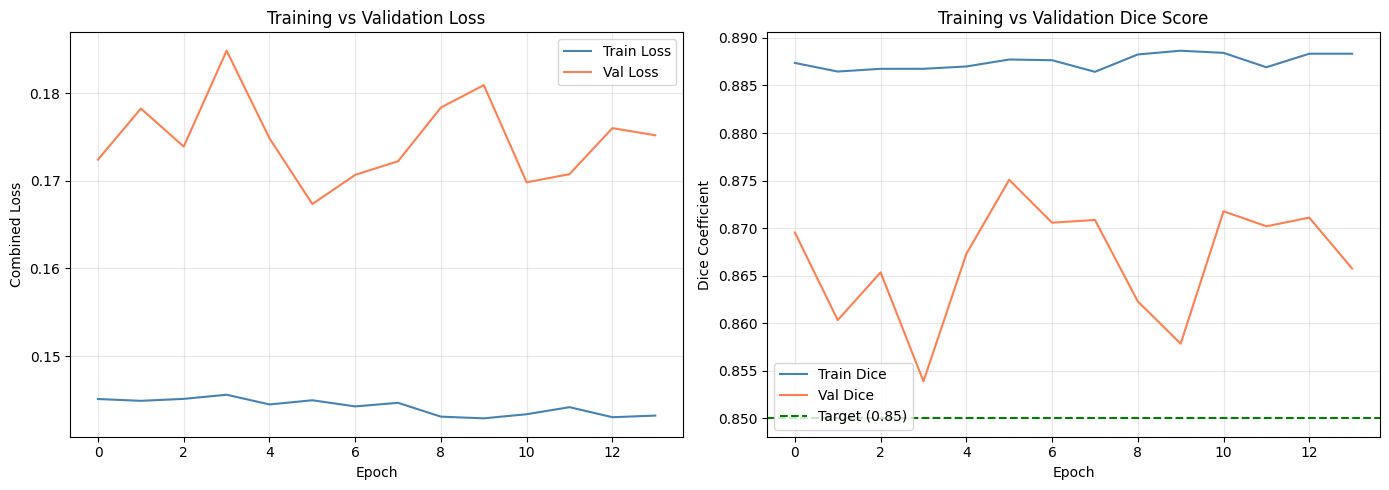

✅ Training curves saved to Drive.


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
axes[0].plot(history.history['loss'],     label='Train Loss', color='steelblue')
axes[0].plot(history.history['val_loss'], label='Val Loss',   color='coral')
axes[0].set_title('Training vs Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Combined Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Dice score curve
axes[1].plot(history.history['dice_coef_per_class'],     label='Train Dice', color='steelblue')
axes[1].plot(history.history['val_dice_coef_per_class'], label='Val Dice',   color='coral')
axes[1].axhline(y=0.85, color='green', linestyle='--', label='Target (0.85)')
axes[1].set_title('Training vs Validation Dice Score')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Dice Coefficient')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/FYP_Tumor_Segmentation/training_curves.png', dpi=150)
plt.show()
print("✅ Training curves saved to Drive.")

🔍 Scanning pipeline for a slice containing a tumor...
🎯 Target Acquired! Visualizing slice with active tumor geometry.



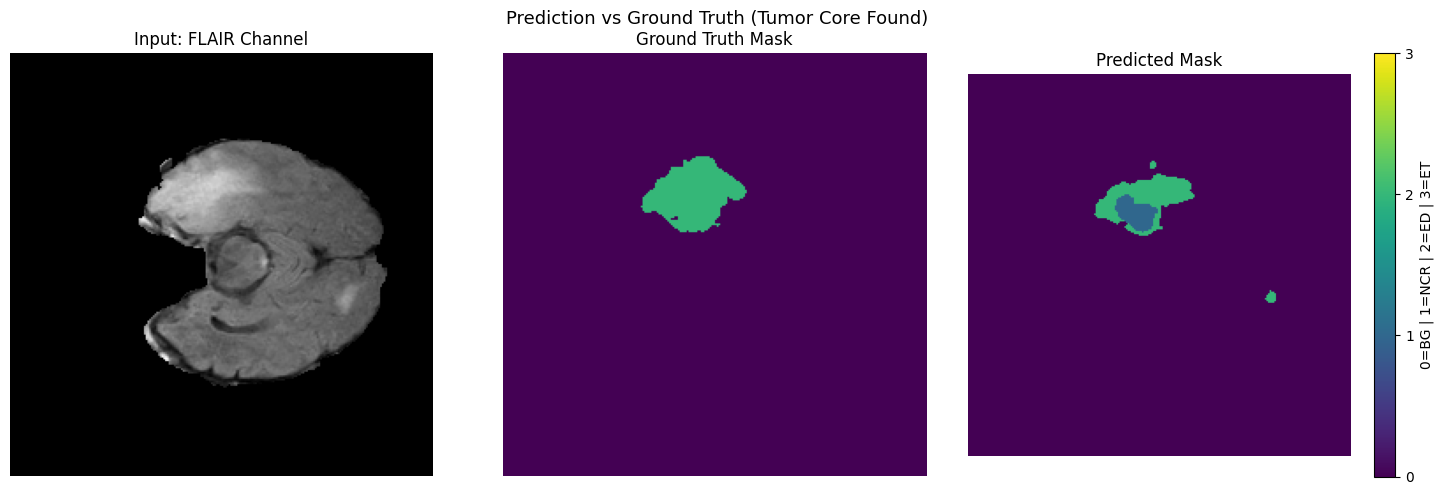


📊 Per-class Dice Scores:
   Class 0 (Background               ): Dice = 0.9960
   Class 1 (NCR (Core)               ): Dice = 0.0000
   Class 2 (Oedema (ED)              ): Dice = 0.6822
   Class 3 (Enhancing Tumour (ET)    ): Dice = 1.0000


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

print("🔍 Scanning pipeline for a slice containing a tumor...")

tumor_found = False

# Loop through the pipeline batches
for val_images, val_masks in val_dataset_final:

    # Check the 4 slices in the current batch
    for i in range(val_images.shape[0]):
        y_true_onehot = val_masks[i:i+1]
        y_true = np.argmax(y_true_onehot[0], axis=-1)

        # TUMOR RADAR: Check if this slice has more than 1500 tumor pixels (Classes 1, 2, or 3)
        if np.sum(y_true > 0) > 1500:
            print(f"🎯 Target Acquired! Visualizing slice with active tumor geometry.\n")

            x_sample = val_images[i:i+1]
            y_pred_prob = model.predict(x_sample, verbose=0)
            y_pred = np.argmax(y_pred_prob[0], axis=-1)
            flair_channel = x_sample[0, :, :, 3]

            # --- PLOTTING ---
            fig, axes = plt.subplots(1, 3, figsize=(15, 5))

            axes[0].imshow(flair_channel, cmap='gray')
            axes[0].set_title('Input: FLAIR Channel', fontsize=12)
            axes[0].axis('off')

            axes[1].imshow(y_true, cmap='viridis', vmin=0, vmax=3)
            axes[1].set_title('Ground Truth Mask', fontsize=12)
            axes[1].axis('off')

            im = axes[2].imshow(y_pred, cmap='viridis', vmin=0, vmax=3)
            axes[2].set_title('Predicted Mask', fontsize=12)
            axes[2].axis('off')

            plt.colorbar(im, ax=axes[2], ticks=[0,1,2,3],
                         label='0=BG | 1=NCR | 2=ED | 3=ET')
            plt.suptitle('Prediction vs Ground Truth (Tumor Core Found)', fontsize=13)
            plt.tight_layout()

            plt.savefig('/content/drive/MyDrive/FYP_Tumor_Segmentation/prediction_active_tumor.png', dpi=150)
            plt.show()

            # --- DICE SCORES ---
            print(f"\n📊 Per-class Dice Scores:")
            CLASS_NAMES = ['Background', 'NCR (Core)', 'Oedema (ED)', 'Enhancing Tumour (ET)']
            for c in range(4):
                true_c = (y_true == c).astype(float)
                pred_c = (y_pred == c).astype(float)
                intersection = np.sum(true_c * pred_c)
                dice = (2 * intersection + 1e-6) / (np.sum(true_c) + np.sum(pred_c) + 1e-6)
                print(f"   Class {c} ({CLASS_NAMES[c]:25s}): Dice = {dice:.4f}")

            tumor_found = True
            break # Stop checking this batch

    if tumor_found:
        break # Stop pulling new batches from the generator

🔍 Pulling a batch of unseen data from the high-speed pipeline...

──────────────────────────────────────────────────
Visualizing Validation Slice 1


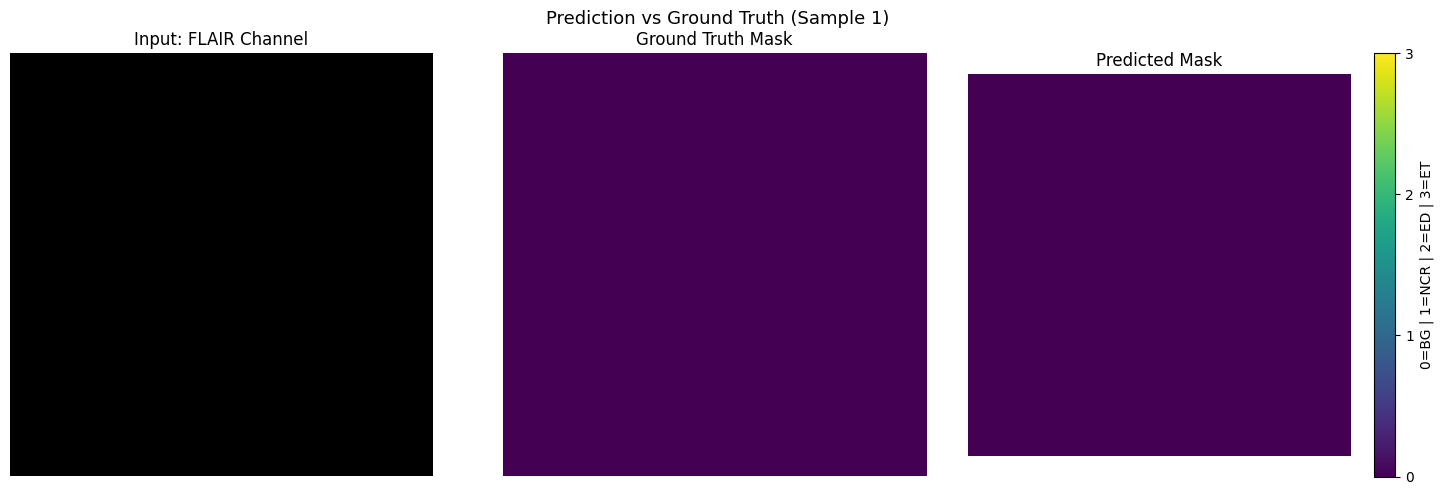


📊 Per-class Dice Scores:
   Class 0 (Background               ): Dice = 1.0000
   Class 1 (NCR (Core)               ): Dice = 1.0000
   Class 2 (Oedema (ED)              ): Dice = 1.0000
   Class 3 (Enhancing Tumour (ET)    ): Dice = 1.0000

──────────────────────────────────────────────────
Visualizing Validation Slice 2


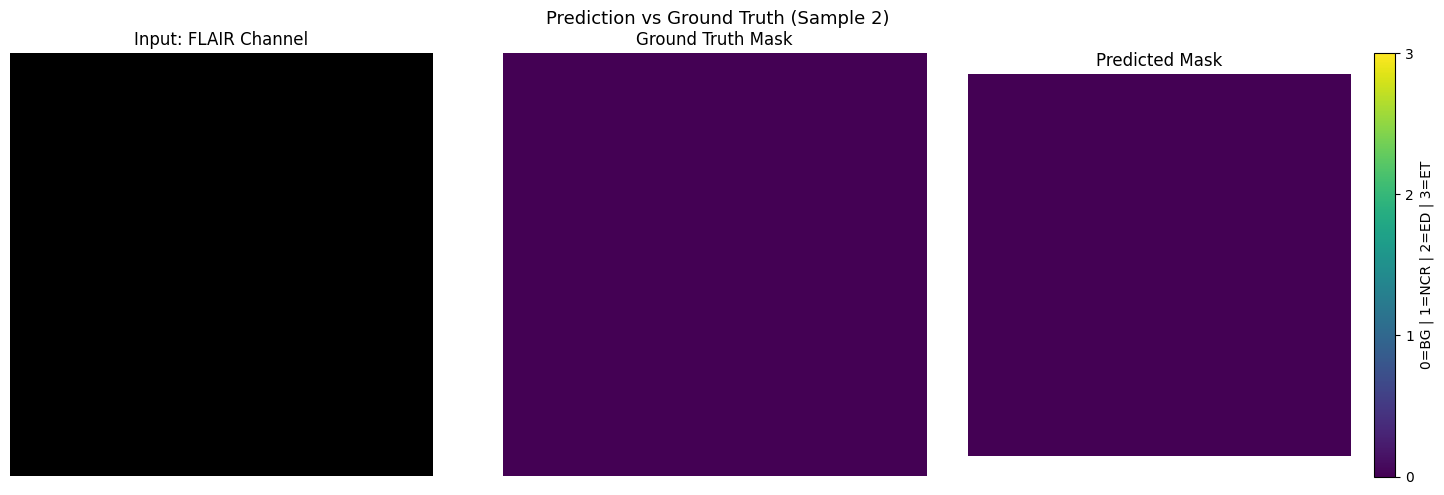


📊 Per-class Dice Scores:
   Class 0 (Background               ): Dice = 1.0000
   Class 1 (NCR (Core)               ): Dice = 1.0000
   Class 2 (Oedema (ED)              ): Dice = 1.0000
   Class 3 (Enhancing Tumour (ET)    ): Dice = 1.0000

──────────────────────────────────────────────────
Visualizing Validation Slice 3


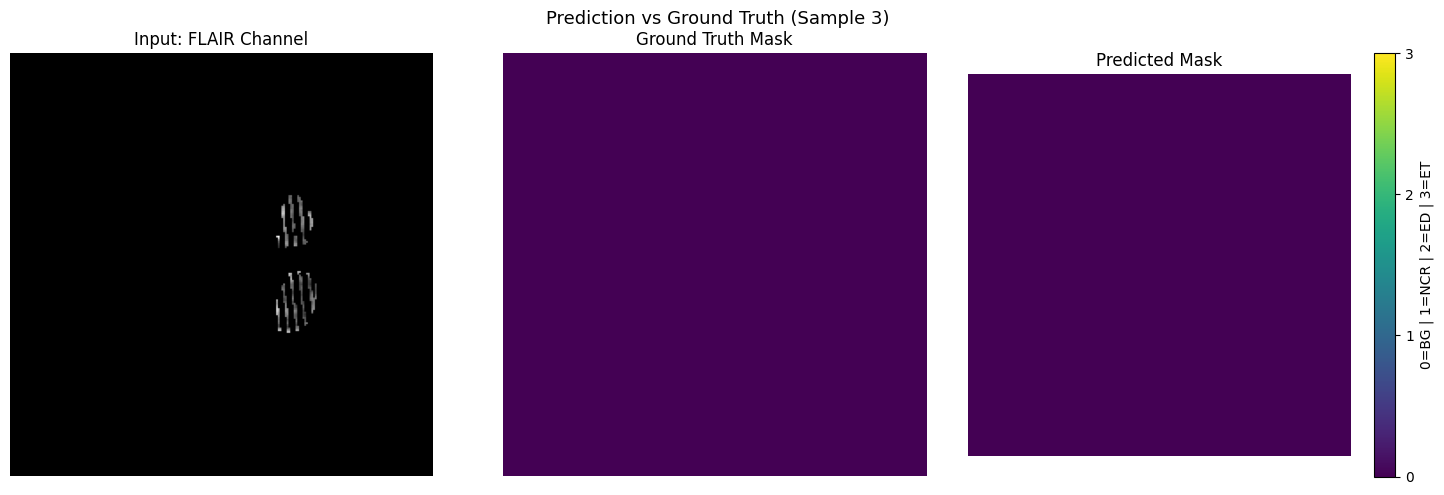


📊 Per-class Dice Scores:
   Class 0 (Background               ): Dice = 1.0000
   Class 1 (NCR (Core)               ): Dice = 1.0000
   Class 2 (Oedema (ED)              ): Dice = 1.0000
   Class 3 (Enhancing Tumour (ET)    ): Dice = 1.0000


In [ ]:
#same function as cell above, but only show first few batches of slices
import matplotlib.pyplot as plt
import numpy as np

print("🔍 Pulling a batch of unseen data from the high-speed pipeline...")

# 1. Pull EXACTLY one batch (4 slices) from your validation generator
for val_images, val_masks in val_dataset_final.take(1):

    # Let's loop through the first 3 slices in this batch
    for i in range(3):
        print(f"\n{'─'*50}")
        print(f"Visualizing Validation Slice {i+1}")

        # Isolate the single slice from the batch
        x_sample = val_images[i:i+1]  # Shape (1, 240, 240, 4)

        # 2. CRITICAL FIX: Convert Ground Truth back from One-Hot Encoding to Integers (0,1,2,3)
        y_true_onehot = val_masks[i:i+1]
        y_true = np.argmax(y_true_onehot[0], axis=-1) # Shape (240, 240)

        # 3. Ask the trained U-Net to predict
        y_pred_prob = model.predict(x_sample, verbose=0)
        y_pred = np.argmax(y_pred_prob[0], axis=-1)   # Shape (240, 240)

        # 4. Extract FLAIR channel for the input visualization
        flair_channel = x_sample[0, :, :, 3]

        # --- PLOTTING ---
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))

        axes[0].imshow(flair_channel, cmap='gray')
        axes[0].set_title('Input: FLAIR Channel', fontsize=12)
        axes[0].axis('off')

        axes[1].imshow(y_true, cmap='viridis', vmin=0, vmax=3)
        axes[1].set_title('Ground Truth Mask', fontsize=12)
        axes[1].axis('off')

        im = axes[2].imshow(y_pred, cmap='viridis', vmin=0, vmax=3)
        axes[2].set_title('Predicted Mask', fontsize=12)
        axes[2].axis('off')

        plt.colorbar(im, ax=axes[2], ticks=[0,1,2,3],
                     label='0=BG | 1=NCR | 2=ED | 3=ET')
        plt.suptitle(f'Prediction vs Ground Truth (Sample {i+1})', fontsize=13)
        plt.tight_layout()

        # FIX: Dynamic filename so you save all 3 separate images to your Drive!
        save_path = f'/content/drive/MyDrive/FYP_Tumor_Segmentation/prediction_sample_{i+1}.png'
        plt.savefig(save_path, dpi=150)
        plt.show()

        # --- DICE SCORES ---
        print(f"\n📊 Per-class Dice Scores:")
        CLASS_NAMES = ['Background', 'NCR (Core)', 'Oedema (ED)', 'Enhancing Tumour (ET)']
        for c in range(4):
            true_c = (y_true == c).astype(float)
            pred_c = (y_pred == c).astype(float)
            intersection = np.sum(true_c * pred_c)
            dice = (2 * intersection + 1e-6) / (np.sum(true_c) + np.sum(pred_c) + 1e-6)
            print(f"   Class {c} ({CLASS_NAMES[c]:25s}): Dice = {dice:.4f}")

In [ ]:
#Quantitative Evaluation Script
import numpy as np
from tqdm import tqdm

print("🧮 Initiating Global Quantitative Performance Analysis...")
print("Extracting 800 unseen validation slices for statistical aggregation...\n")

# 1. Setup Accumulators for Base Classes (0, 1, 2, 3)
intersection_cls = np.zeros(4)
union_cls = np.zeros(4)
sum_true_cls = np.zeros(4)
sum_pred_cls = np.zeros(4)

# 2. Setup Accumulators for Clinical Regions (WT, TC, ET)
intersection_clin = np.zeros(3)
union_clin = np.zeros(3)
sum_true_clin = np.zeros(3)
sum_pred_clin = np.zeros(3)

correct_pixels = 0
total_pixels = 0

# 3. Iterate through 200 batches (800 slices total with batch size 4)
for val_images, val_masks in tqdm(val_dataset_final.take(200), total=200, desc="Evaluating Batches"):

    # Predict and decode one-hot encoding
    y_pred_prob = model.predict(val_images, verbose=0)
    y_pred = np.argmax(y_pred_prob, axis=-1)
    y_true = np.argmax(val_masks.numpy(), axis=-1)

    # Global Pixel Accuracy
    correct_pixels += np.sum(y_true == y_pred)
    total_pixels += y_true.size

    # Calculate Per-Class Metrics
    for c in range(4):
        true_c = (y_true == c)
        pred_c = (y_pred == c)

        intersection_cls[c] += np.sum(true_c & pred_c)
        union_cls[c] += np.sum(true_c | pred_c)
        sum_true_cls[c] += np.sum(true_c)
        sum_pred_cls[c] += np.sum(pred_c)

    # Calculate Clinical Regions
    # Whole Tumor (WT) = Classes > 0
    true_wt = (y_true > 0)
    pred_wt = (y_pred > 0)
    intersection_clin[0] += np.sum(true_wt & pred_wt)
    union_clin[0] += np.sum(true_wt | pred_wt)
    sum_true_clin[0] += np.sum(true_wt)
    sum_pred_clin[0] += np.sum(pred_wt)

    # Tumor Core (TC) = Classes 1 and 3
    true_tc = np.isin(y_true, [1, 3])
    pred_tc = np.isin(y_pred, [1, 3])
    intersection_clin[1] += np.sum(true_tc & pred_tc)
    union_clin[1] += np.sum(true_tc | pred_tc)
    sum_true_clin[1] += np.sum(true_tc)
    sum_pred_clin[1] += np.sum(pred_tc)

    # Enhancing Tumor (ET) = Class 3
    true_et = (y_true == 3)
    pred_et = (y_pred == 3)
    intersection_clin[2] += np.sum(true_et & pred_et)
    union_clin[2] += np.sum(true_et | pred_et)
    sum_true_clin[2] += np.sum(true_et)
    sum_pred_clin[2] += np.sum(pred_et)

# 4. Final Math Calculations (Adding 1e-6 to prevent divide-by-zero)
pixel_acc = correct_pixels / total_pixels
dice_cls = (2 * intersection_cls + 1e-6) / (sum_true_cls + sum_pred_cls + 1e-6)
iou_cls = (intersection_cls + 1e-6) / (union_cls + 1e-6)

dice_clin = (2 * intersection_clin + 1e-6) / (sum_true_clin + sum_pred_clin + 1e-6)
iou_clin = (intersection_clin + 1e-6) / (union_clin + 1e-6)

# 5. Print the beautifully formatted results
print(f"\n{'='*50}")
print(f"🌟 GLOBAL QUANTITATIVE RESULTS (800 Slices) 🌟")
print(f"{'='*50}")
print(f"Global Pixel Accuracy: {pixel_acc * 100:.2f}%\n")

print(f"--- INDIVIDUAL CLASSES ---")
CLASS_NAMES = ['0: Background', '1: NCR (Core)', '2: Oedema', '3: Enhancing']
for i in range(4):
    print(f"{CLASS_NAMES[i]:<15} | Dice: {dice_cls[i]:.4f} | IoU: {iou_cls[i]:.4f}")

print(f"\n--- CLINICAL REGIONS ---")
CLIN_NAMES = ['Whole Tumor (WT)', 'Tumor Core (TC)', 'Enhancing (ET)']
for i in range(3):
    print(f"{CLIN_NAMES[i]:<16} | Dice: {dice_clin[i]:.4f} | IoU: {iou_clin[i]:.4f}")
print(f"{'='*50}")

🧮 Initiating Global Quantitative Performance Analysis...
Extracting 800 unseen validation slices for statistical aggregation...



Evaluating Batches: 100%|██████████| 200/200 [00:22<00:00,  8.83it/s]


🌟 GLOBAL QUANTITATIVE RESULTS (800 Slices) 🌟
Global Pixel Accuracy: 99.33%

--- INDIVIDUAL CLASSES ---
0: Background   | Dice: 0.9983 | IoU: 0.9965
1: NCR (Core)   | Dice: 0.6683 | IoU: 0.5019
2: Oedema       | Dice: 0.6816 | IoU: 0.5170
3: Enhancing    | Dice: 0.6017 | IoU: 0.4303

--- CLINICAL REGIONS ---
Whole Tumor (WT) | Dice: 0.8867 | IoU: 0.7965
Tumor Core (TC)  | Dice: 0.7294 | IoU: 0.5740
Enhancing (ET)   | Dice: 0.6017 | IoU: 0.4303
